In [12]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.plots import plot_uncertainty_distributions, plot_combined_uncertainty_analysis
from lib.utils import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""

dataset = 'pd_neuro'
analysis_name = 'pd_dyskinesia'
outcome_name = 'FutureDyskinesia'
build_ensemble_csv(analysis_name, outcome_name)


active_at_bl = pd.read_csv(f'../data/{dataset}/clusters/active_neuro_dyskinesia.csv')
all_patients = pd.read_csv(f'../data/{dataset}/X_neuroart_v4.csv')
# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.index = patients_stats['idx']

# remove patient in postion 87 from all_patients and active_at_bl because this patiente is never tested
all_patients = all_patients.drop(index=87)

# remove from full training preds the active patients at bl
non_active_idx = all_patients.index[~all_patients.index.isin(active_at_bl['Unnamed: 0'])]


all_patients_non_active = all_patients[all_patients.index.isin(non_active_idx)]

# filter out active patients at bl from the mean training predictions
patients_stats_filtered = patients_stats[patients_stats['idx'].isin(non_active_idx)]

# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats_filtered['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats_filtered['idx'].values)

Successfully aggregated 10500 predictions across 246 unique patients.


Baseline entropy: 0.8718686865491422


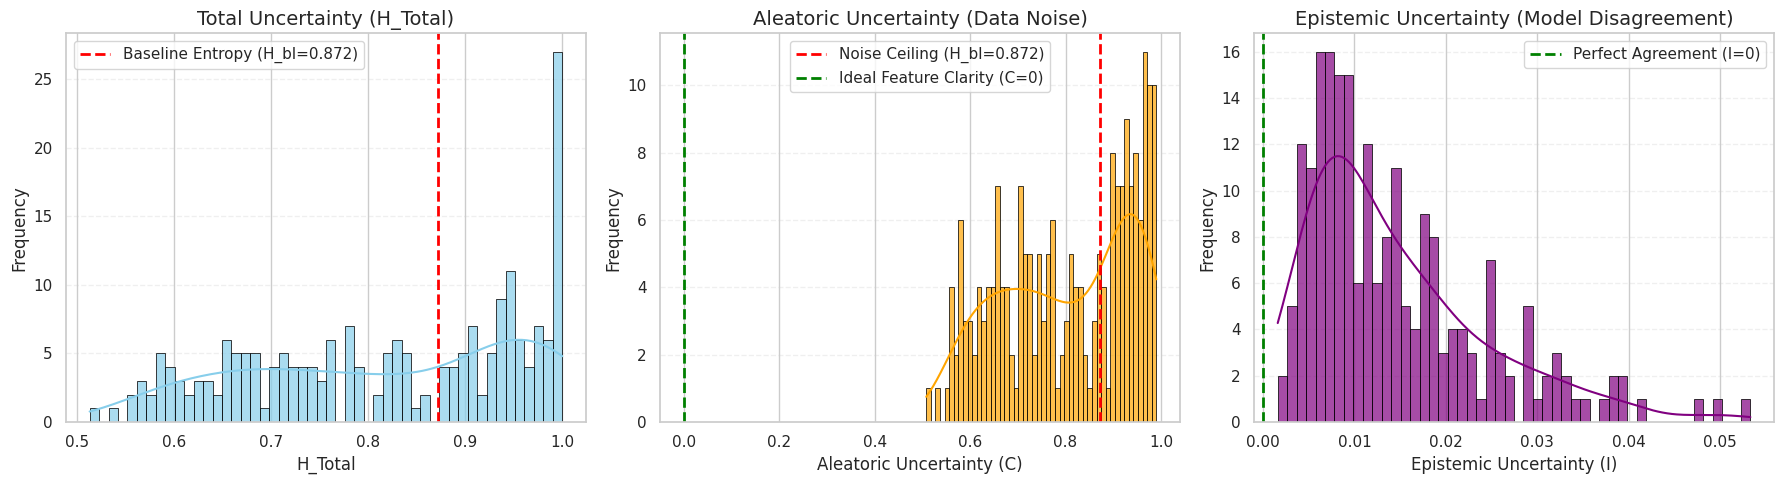

In [13]:
# Compute uncertainties for the non-active patients at baseline


uncertainty_results = compute_uncertainties(probs_raw_df)

# Create an explicit copy to avoid SettingWithCopyWarning
patients_stats_filtered = patients_stats_filtered.copy()

# 2. Add the results to your main stats table
patients_stats_filtered['H_Total'] = uncertainty_results['H_Total']
patients_stats_filtered['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
patients_stats_filtered['I_Epistemic'] = uncertainty_results['I_Epistemic']


# Compute the baseline risk (mean of probs_cal across all folds) for each patient and its uncertainty value 
proportion_positive = all_patients_non_active['FutureDyskinesia'].sum() / len(all_patients_non_active)
H_bl = -(proportion_positive * np.log2(proportion_positive + 1e-12) +
         (1 - proportion_positive) * np.log2(1 - proportion_positive + 1e-12))
print("Baseline entropy:", H_bl)



plot_uncertainty_distributions(
     uncertainty_results, 
     H_bl, 
     #save_path='../results/uncertainty/plots/uncertainty_distributions.png'
 )

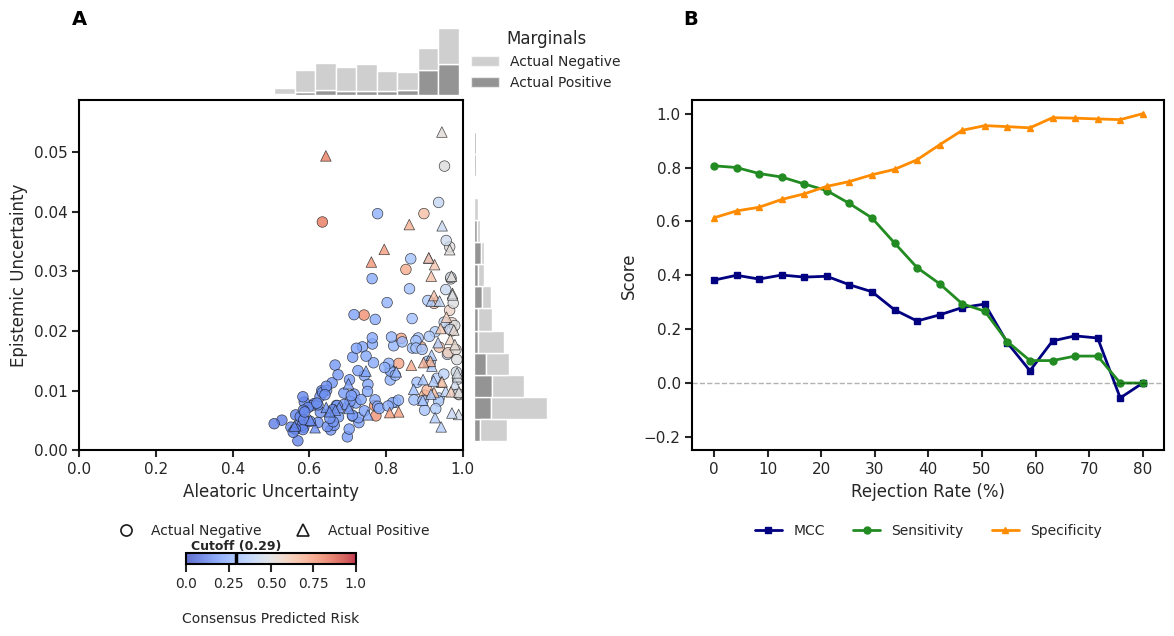

In [14]:
plot_combined_uncertainty_analysis(patients_stats_filtered, all_patients_non_active['FutureDyskinesia'])
# quanti sample in classe positiva e in classe negativa per ogni rejection threshold.
# per ogni rejection threshold calcola anche la uncertainty di questi soggetti scartati



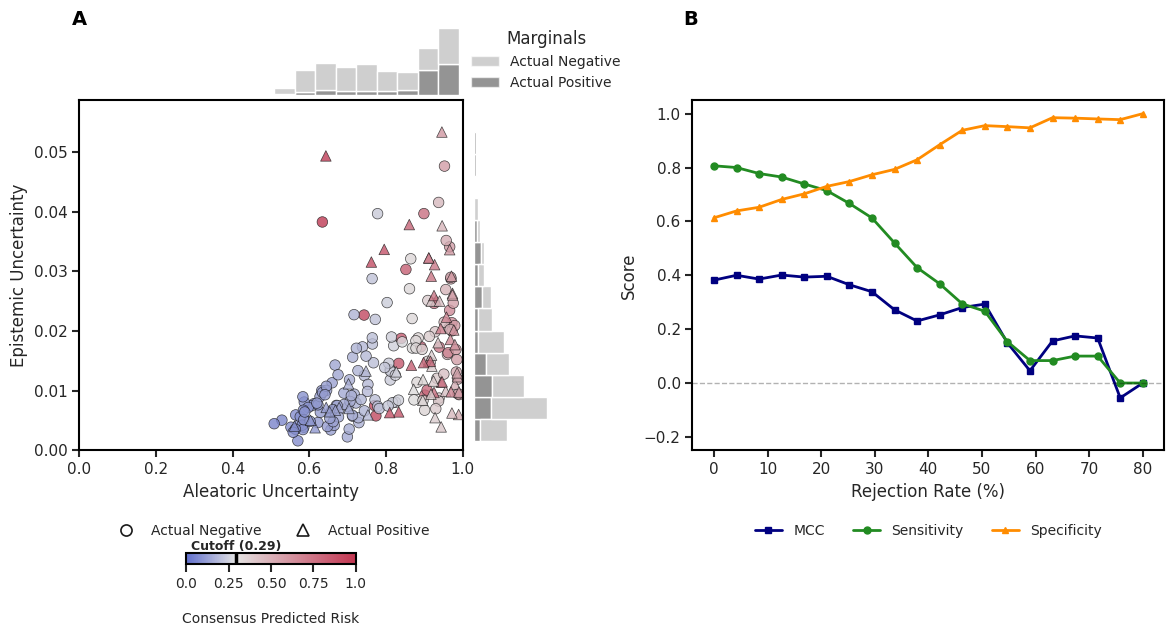

In [15]:
from lib.plots import plot_combined_uncertainty_analysis_v2


plot_combined_uncertainty_analysis_v2(patients_stats_filtered, all_patients_non_active['FutureDyskinesia'])

## Explore clinical data through GMM analysis
There's a clear separation between patients. The two scores agree on the number of clusters. For this PD dataset we are going to do GMM analysis to see how the two clusters differ in terms of clinical features. Finally we're going to see how rejection curves differ between the two clusters.

Number of original clinical features: 27
Optimal PCs according to the Kaiser Rule: 9

Top 5 Eigenvalues:
[4.28 2.9  1.9  1.65 1.4 ]


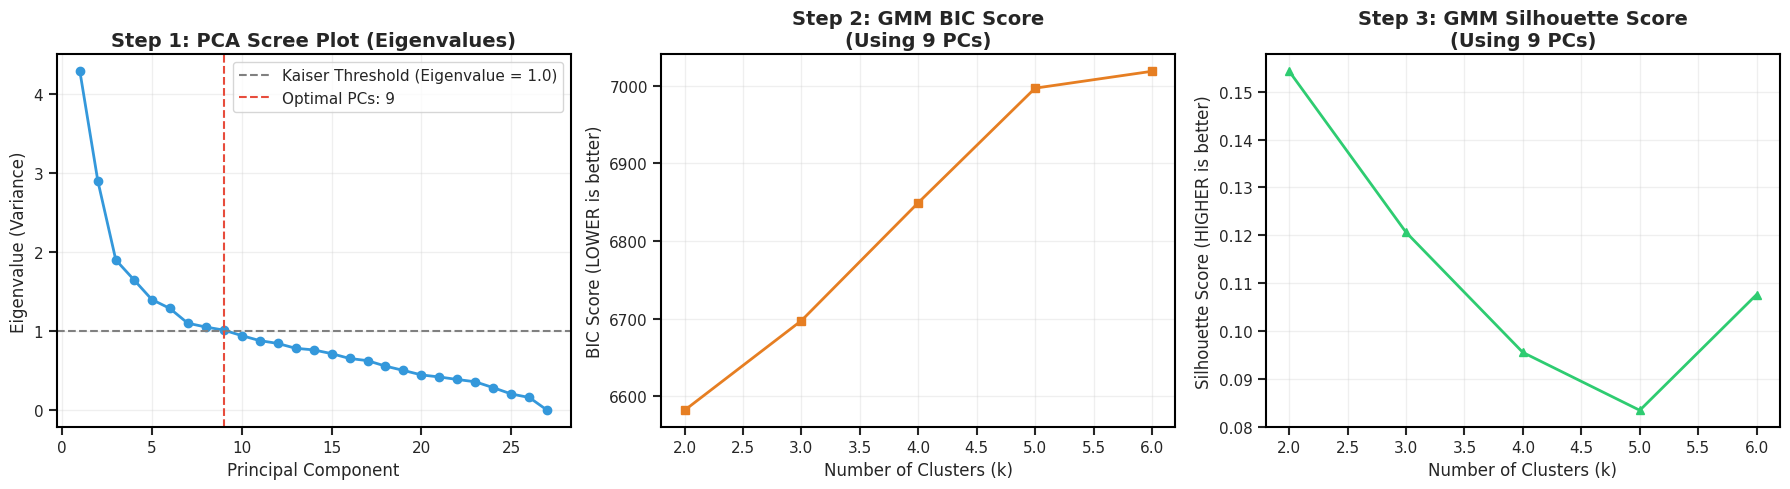


--- Optimization Results ---
1. Optimal PCs retained (Kaiser Rule, Eigenvalue > 1.0): 9
2. Best GMM model according to BIC (lowest complexity penalty): k = 2
3. Best GMM model according to Silhouette (highest separation): k = 2


In [16]:
from lib.clustering import optimize_pca_and_gmm_kaiser


X_clinical = all_patients_non_active.drop(columns=['FutureDyskinesia', 'PatientID', 'Center', 
                                                   'FutureMotorFluctuations', 'max_status_longi', 'FutureFalls', 
                                                   'FutureFreezing'])

optimize_pca_and_gmm_kaiser(X_clinical, max_clusters=6)

In [17]:
""" Run gmm clustering and analyze the two clusters"""

# 1. Prepare Data
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.mixture import GaussianMixture

from lib.clustering import profile_clinical_clusters


imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_clinical)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca_opt = PCA(n_components=9, random_state=42)
X_pca = pca_opt.fit_transform(X_scaled)

final_gmm = GaussianMixture(n_components=2, random_state=42, n_init=10)
clusters = final_gmm.fit_predict(X_pca)

cluster_probs = final_gmm.predict_proba(X_pca)

phenotype_labels = np.where(clusters == 0, 'Phenotype A (Predictable - advanced)', 'Phenotype B (Invisible - mild)')

patients_stats_filtered['Phenotype'] = phenotype_labels

clinical_profile = profile_clinical_clusters(X_clinical, patients_stats_filtered)

--- Clinical Signature of the Phenotypes ---
 Clinical_Feature  Mean_Phenotype_A  Mean_Phenotype_B P_Value
MotorFluctuations              0.38              0.02  <0.001
             ledd            449.56            164.35  <0.001
 DiseaseYearsAtBL              1.03              0.24  <0.001
         Freezing              0.27              0.00  <0.001
    LevodopaYears              4.30              1.15  <0.001
            Falls              0.26              0.00  <0.001
  CognitiveStatus              0.32              0.00  <0.001
              ICD              0.23              0.00  <0.001
   LevodopaBinary              0.87              0.53  <0.001
              H&Y              2.05              1.65  <0.001


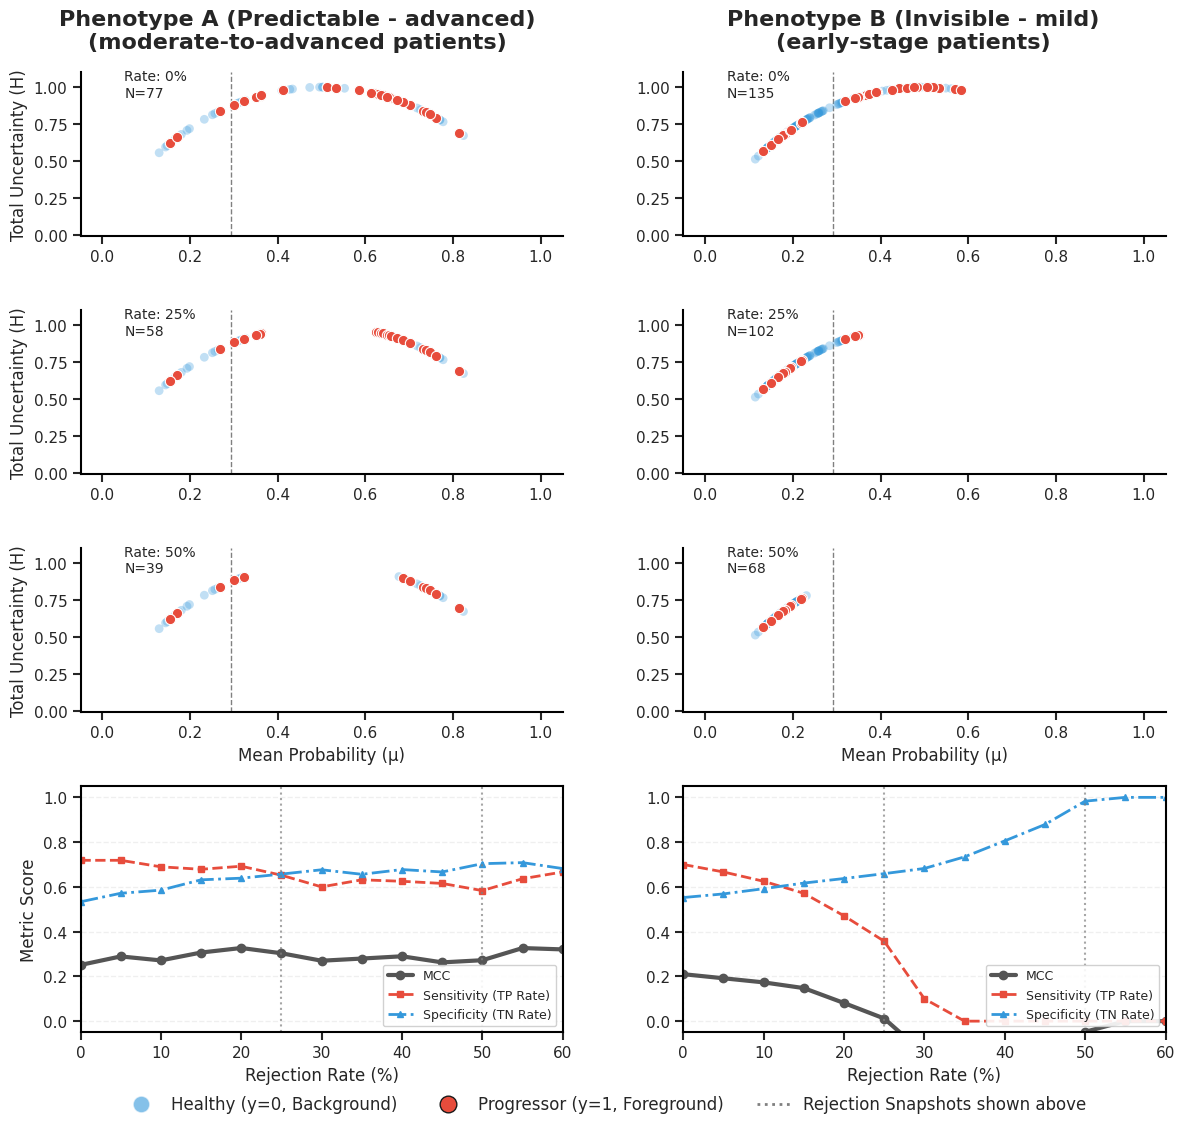

In [18]:
from lib.clustering import generate_forensic_dashboard


generate_forensic_dashboard(patients_stats_filtered, 'H_Total')

## Conditioned Classification Rejection Curves (CCRC)

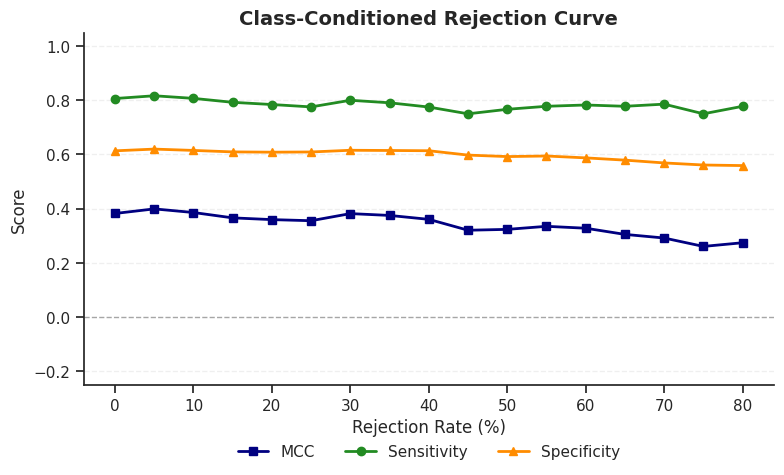

GLOBAL CLASS-CONDITIONED REJECTION: METRICS EVOLUTION
 Rejection (%)  Total Kept  TP  FP  TN  FN   MCC  Sensitivity  Specificity
             0         212  50  58  92  12 0.382        0.806        0.613
             5         202  49  54  88  11 0.399        0.817        0.620
            10         192  46  52  83  11 0.386        0.807        0.615
            15         181  42  50  78  11 0.366        0.792        0.609
            20         171  40  47  73  11 0.359        0.784        0.608
            25         159  38  43  67  11 0.355        0.776        0.609
            30         149  36  40  64   9 0.382        0.800        0.615
            35         139  34  37  59   9 0.375        0.791        0.615
            40         128  31  34  54   9 0.360        0.775        0.614
            45         118  27  33  49   9 0.320        0.750        0.598
            50         106  23  31  45   7 0.323        0.767        0.592
            55          96  21  28  41   6 0.3

In [19]:
from lib.plots import plot_class_conditioned_rejection_curve


optimal_threshold = all_patients_non_active['FutureDyskinesia'].mean()

class_cond_results = plot_class_conditioned_rejection_curve(
    patients_stats_filtered, 
    threshold=optimal_threshold, 
    uncertainty_col='H_Total',
    rates=np.linspace(0, 80, 17)
)

# ---- anche per class conditioned dividendo l'analisi per classe positiva e negativa (quindi 4 grafici: 2 per classe e 2 per class conditioned)
# quanti sample in classe positiva e in classe negativa per ogni rejection threshold.
# per ogni rejection threshold calcola anche la uncertainty di questi soggetti scartati
# plot delle distribuzioni di uncertainty dei soggetti scartati per ogni classe e per ogni rejection threshold

### Confusion matrix evolution analysis

Standard global rejection frameworks fail in clinical datasets because predicting the onset of a future disease (Class 1) is inherently noisier than diagnosing baseline stability (Class 0). This Asymmetric Aleatoric Uncertainty causes standard algorithms to disproportionately delete the positive class, crashing the Sensitivity to zero.

By implementing Class-Conditioned Rejection tied to the baseline prior, we successfully decoupled the rejection threshold from this asymmetric noise.
Dataset 2 (The PD Cohort | Prior ~0.40) -> The "Preservation" Mechanism

Observation: The baseline model is already highly performant (Sens: ~0.80, MCC: ~0.38) because the data has better biological separation, but the prediction remains fundamentally asymmetric in difficulty.

Impact: Class-Conditioned Rejection acts as a preservation tool. Even as we delete up to 50% of the dataset, the Sensitivity barely flinches (hovering tightly between 0.78 - 0.81).

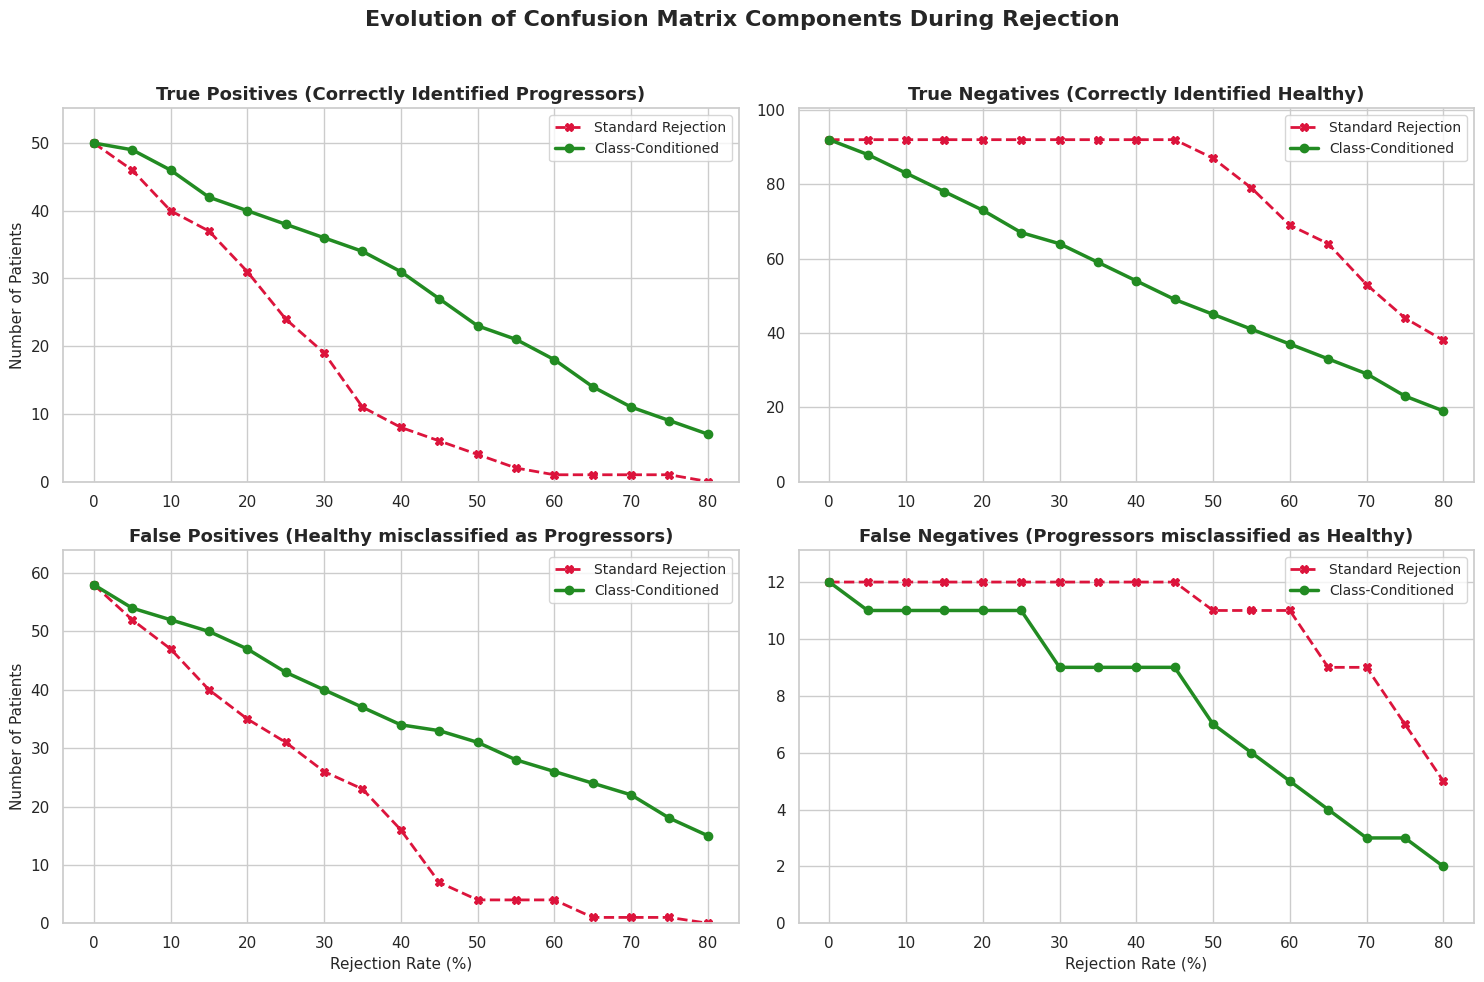

In [20]:

# Example Call:
from lib.plots import plot_comprehensive_rejection_dashboard


optimal_threshold = all_patients_non_active['FutureDyskinesia'].mean()
dashboard_results = plot_comprehensive_rejection_dashboard(patients_stats_filtered, threshold=optimal_threshold)

In [21]:



from lib.utils import extract_and_analyze_rejection


optimal_threshold = all_patients_non_active['FutureDyskinesia'].mean()

# Extract the patients at a 25% rejection rate
kept_df, removed_df, uncertainty_stats = extract_and_analyze_rejection(
     patients_stats_filtered,
     prior_threshold=optimal_threshold,
     rate=25,
     method='class_conditioned',
     sort_col='H_Total',
     uncertainty_cols=['H_Total', 'C_Aleatoric', 'I_Epistemic', 'sigma']
)

REJECTION AUDIT: CLASS_CONDITIONED @ 25%
Total Cohort:    212 patients
Total Kept:      159 patients
Total Removed:   53 patients
--------------------------------------------------------------------------------
UNCERTAINTY PROFILE COMPARISON:
     Metric  Kept_Profile Removed_Profile P_Value
    H_Total 0.791 ± 0.143   0.906 ± 0.096  <0.001
C_Aleatoric 0.777 ± 0.138   0.887 ± 0.093  <0.001
I_Epistemic 0.013 ± 0.009   0.019 ± 0.010  <0.001
      sigma 0.057 ± 0.024   0.074 ± 0.022  <0.001


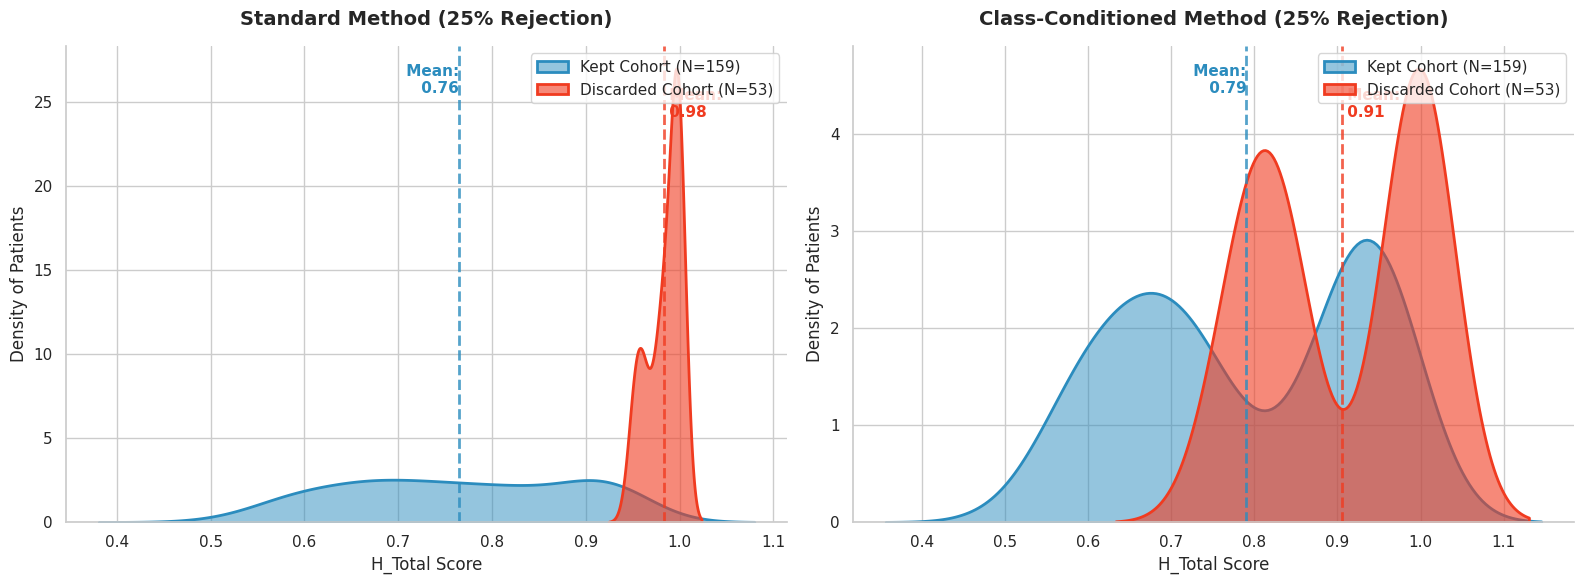

In [22]:
from lib.plots import plot_side_by_side_distributions

# --- Example Usage ---
optimal_threshold = all_patients_non_active['FutureDyskinesia'].mean()
plot_side_by_side_distributions(patients_stats_filtered, threshold=optimal_threshold, rate=25)


Density distributions of total uncertainty ($H_{Total}$) for kept versus discarded patient cohorts at a 25% rejection rate. > (Left) Standard global rejection behaves as a strict thresholding mechanism, entirely severing the right tail of the uncertainty distribution. Because positive/incident predictions carry inherently higher aleatoric noise, this strict cutoff disproportionately discards the minority class.
(Right) The proposed Class-Conditioned rejection method calculates proportional uncertainty cutoffs decoupled by predicted class. This creates a bimodal, overlapping rejection boundary that safely discards highly uncertain negative predictions while retaining higher-uncertainty positive predictions, accounting for the asymmetric biological difficulty of the classes and preserving model sensitivity.